## Geometries Exercise

Laurent wants to buy a house in Sierre. He went to visit 3 properties and he collected the coordinates in this file: data/simple-geometries/exercise-geometries.txt

### 1. Read the text file

In [62]:
f = open ('../../data/simple-geometries/geometries.json') 

We can open the file using the regular python `open` function. 

### 2. Explore the file contents

The file contains coordinates of: terrains, houses, swimming pool, river, road, university and train station.

You will notice that each line contians information about an object (e.g., house, road)
Data is separated by `;`. 
The second field is the type of object. 
The third is the name of the object (e.g. 'H1'). 
The rest of the fields are pair coordinates x,y separated by `,`.  

In [63]:
data = f.read()
f.close()
data

'{\n  "type": "FeatureCollection",\n  "features": [\n    {\n      "type": "Feature",\n      "properties": {\n        "stroke": "#555555",\n        "stroke-width": 2,\n        "stroke-opacity": 1,\n        "fill": "#555555",\n        "fill-opacity": 0.5,\n        "type": "terrain",\n        "name": "Terrain-A"\n      },\n      "geometry": {\n        "type": "Polygon",\n        "coordinates": [\n          [\n            [\n              7.535770833492279,\n              46.29209752598038\n            ],\n            [\n              7.535832524299621,\n              46.29196223064501\n            ],\n            [\n              7.536106109619141,\n              46.29214756663618\n            ],\n            [\n              7.5359907746315,\n              46.29223652768917\n            ],\n            [\n              7.535816431045532,\n              46.29220872737563\n            ],\n            [\n              7.535770833492279,\n              46.29209752598038\n            ]\n     

We can iterate over the file lines or, as in this case read all lines at once, as it is a short file. 

We can explore the file contents retrieved in the `data` list. 
Notice that each element in the list is a long string with all the contents. We will still need to separate all elements by `;`.

In [64]:
import json
from types import SimpleNamespace


geojson = json.loads(data)
geojson['type']

geojson=json.loads(data, object_hook=lambda d: SimpleNamespace(**d))
geojson.features

[namespace(geometry=namespace(coordinates=[[[7.535770833492279, 46.29209752598038], [7.535832524299621, 46.29196223064501], [7.536106109619141, 46.29214756663618], [7.5359907746315, 46.29223652768917], [7.535816431045532, 46.29220872737563], [7.535770833492279, 46.29209752598038]]], type='Polygon'), properties=namespace(fill='#555555', fill-opacity=0.5, name='Terrain-A', stroke='#555555', stroke-opacity=1, stroke-width=2, type='terrain'), type='Feature'),
 namespace(geometry=namespace(coordinates=[[[7.536124885082244, 46.29241630270935], [7.5362858176231375, 46.29220316731123], [7.536532580852508, 46.29243668953004], [7.536296546459199, 46.29272210422308], [7.536073923110961, 46.29255715695201], [7.536124885082244, 46.29241630270935]]], type='Polygon'), properties=namespace(fill='#555555', fill-opacity=0.5, name='Terrain-B', stroke='#555555', stroke-opacity=1, stroke-width=2, type='terrain'), type='Feature'),
 namespace(geometry=namespace(coordinates=[[[7.535186111927033, 46.2916323310

In [65]:
features=geojson.features
features[0].geometry.type


'Polygon'

### 3. Create geometries for each type of object in the file

`Polygon` for terrains,houses, pool. 
`LineString` for river, road, 
`Point` for station and university. 
You will notice, for example, that the train station only has one pair of x, y coordinates, so it's a point. A house, you will notice, has more coordinates, and it's a polygon. 

In [66]:
from shapely.geometry import Polygon
from shapely.geometry import LineString
from shapely.geometry import Point
from shapely.geometry import GeometryCollection

First we import all the geometry types that we may need to use.

Then, the next step is iterate through the file content taht we have put in the `data` list and convert the coordinates into a `Polygon`, `LineString` or `Point`.  

There are lots of ways to do that. To illustrate the use of python classes, we are going to create a class `GeoObject` that represents a geometric object, one for each line of the fil.

Each `GeoObject` will have three fields: `name`, `objectType` and `geom`, which correspond to the geometry name, type of object (road, house, etc.) and geometric object (point, polygon, line string).


In [67]:
for f in features:
    print(f.geometry.coordinates)
    if f.geometry.type == 'Point' :
        f.geo=Point(f.geometry.coordinates)
    elif f.geometry.type == 'LineString' :
        f.geo=LineString(f.geometry.coordinates)
    elif f.geometry.type == 'Polygon' :
        #print("coco",f.geometry.coordinates)
        f.geo=Polygon(f.geometry.coordinates[0])
        

[[[7.535770833492279, 46.29209752598038], [7.535832524299621, 46.29196223064501], [7.536106109619141, 46.29214756663618], [7.5359907746315, 46.29223652768917], [7.535816431045532, 46.29220872737563], [7.535770833492279, 46.29209752598038]]]
[[[7.536124885082244, 46.29241630270935], [7.5362858176231375, 46.29220316731123], [7.536532580852508, 46.29243668953004], [7.536296546459199, 46.29272210422308], [7.536073923110961, 46.29255715695201], [7.536124885082244, 46.29241630270935]]]
[[[7.535186111927033, 46.291632331028985], [7.535373866558075, 46.29152298184133], [7.535583078861236, 46.29157302302211], [7.535566985607147, 46.291758360330334], [7.535186111927033, 46.291632331028985]]]
[[[7.536170482635499, 46.29244039622391], [7.536371648311614, 46.29244039622391], [7.536371648311614, 46.2925237967694], [7.536170482635499, 46.2925237967694], [7.536170482635499, 46.29244039622391]]]
[[[7.535851299762726, 46.292136446494375], [7.5359907746315, 46.292136446494375], [7.5359907746315, 46.29219

In [68]:

    
    class GeoObject(object):    
    def __init__(self,line):
       line=line.split(';')
       self.name=line[2]
       self.objectType=line[1]
       coords=[]
       for c in line[3:]:
          (x,y)=c.split(',')
          coords.append((float(x),float(y)))
       self.createGeometry(coords)
       
    def createGeometry(self,coords):
       objType=self.objectType
       if (objType == 'terrain' or objType=='house' or objType=='pool'):
          self.geom=Polygon(coords)
       elif (objType == 'river' or objType=='road'):
          self.geom=LineString(coords)
       else:
          self.geom=Point(coords)

IndentationError: expected an indented block (<ipython-input-68-37a798a0f173>, line 2)

The class also has one constructor (`__init__`) that has one parameter, the text line from which all information will be extracted. It essentially splits the line by `;`, and splits the coordinates by the separator `,`. Then it calls the method `createGeometry`.

The method `createGeometry` takes the coordinates and depending of the objectType, it will create a different kind of geometry object. For example, if it is a 'road' or 'river', it will create a `LineString`.

Now that the class is defined, we can use it to structure the contents of the file:

In [69]:
geometries=[GeoObject(line.strip()) for line in data]
geometries

NameError: name 'GeoObject' is not defined

Now we have stored a list of `GeoObject` instances in the `geometries` variable.
We can see for example the first of these objects:

In [70]:
print(geometries[0].name,
      geometries[0].objectType,
      geometries[0].geom)

NameError: name 'geometries' is not defined

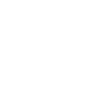

In [71]:
from shapely.geometry.collection import GeometryCollection
onlygeometries=GeometryCollection([g.geo for g in features])
onlygeometries

### 4. Which is the largest house? H1, H2, H3?

Now that all objects are structured and in a list, it will be easier to operate over them.

To answer this question we need to first filter only the houses. We can create a list by comprehension for this filter:

In [72]:
houses = [g for g in features if g.properties.type=='house']

Now we can compare the areas of the houses and keep the largest. In the end we print the `name` of the largest house. 

In [73]:
maxi=0
for h in houses:
   if h.geo.area>maxi:
      maxi=h.geo.area
      bigger=h
bigger.properties.name

'House-3'

As usual, there are many ways to do the same thing. There is a `max` function that takes a list, and a function to select the field to be compared. The result is the same:

In [74]:
bigHouse = max(houses,key=lambda h:h.geo.area )
bigHouse.properties.name

'House-3'

### 5. Which house is contained in which terrain?

First we filter the terrains:

In [75]:
terrains = [g for g in features if g.properties.type=='terrain']

Now we can store in a map called `match` the pairs `{`terrain,house`}`. We iterate over the terrains and also the houses, and compare if the house is `within` the terrain:

In [76]:
match={}
for t in terrains:
    for h in houses:
        if h.geo.within(t.geo):
          match[t.properties.name]=h.properties.name

match

{'Terrain-A': 'House-1', 'Terrain-B': 'House-3', 'Terrain-C': 'House-2'}

### 6. Which terrain is closer to the road? and to the university?

First we get the road, and university. 

In [77]:
roads=filter(lambda r:r.properties.type=='road' ,features)
road=next(roads)

unis=filter(lambda r:r.properties.type=='university' ,features)
uni=next(unis)

Now we can iterate over the terrains, and compute the distance to the road. We keep only the minimum.

In [78]:
minDist=100000
for t in terrains:
    dist=t.geo.distance(road.geo)
    if dist<minDist :
       minDist=dist
       closer=t

closer.properties.name

'Terrain-B'

We can do exactly the same for the university:

In [79]:
minDist=100000
for t in terrains:
    dist=t.geo.distance(uni.geo)
    if dist<minDist :
       minDist=dist
       closer=t

closer.properties.name

'Terrain-B'

### 7. The subterranean river crosses some terrains. Which ones?

Again, we first get the river:

In [80]:
rivers=filter(lambda r:r.properties.type=='river' ,features)
river=next(rivers)

Now we can iterate over the terrains and see which ones intersect with the river:

In [81]:
for t in terrains:
    if t.geo.intersects(river.geo):
      print(t.properties.name)

Terrain-A
Terrain-B


### 8. Which terrain has a swimming pool?

Similar as the previous one, but now we chack if the terrain `contains` the pool:

In [82]:
pools=filter(lambda r:r.properties.type=='pool' ,features)
pool=list(pools)[0]

for t in terrains:
    if t.geo.contains(pool.geo):
      print(t.properties.name)

Terrain-B


### 9. Create a new geometry for a terrain without the surface of the house and swimming pool

For this we first get the terrain that contains the pool (`T-B`), and its house:

In [84]:
terrainB=list(filter(lambda r:r.properties.name=='Terrain-B',terrains))[0]
house3=list(filter(lambda r:r.properties.name=='House-3',houses))[0]

Then, we create the new terrain, computing the `difference`:

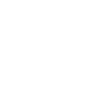

In [85]:
newTerrain=terrainB.geo.difference(house3.geo)
newTerrain=newTerrain.difference(pool.geo)

newTerrain

The new terrain has two 'holes in it'

### 10. Compute the area of a terrain. Is it correct? How about the area of a house?

We can just use the `area` attribute:

In [86]:
terrainB.geo.area

house3.geo.area 

1.6777327122259985e-08

Notice that this number is very small. It is not very meaningful as it is not in any specific unit of measure (sq meters). 
Remember that shapely does not include geographic reference systems. For that we will see other tools and libraries.... :)